In [21]:
import torch
import torchvision.transforms as T
from PIL import Image
import numpy as np
from tqdm.auto import tqdm
from Utils.utils import *
from torch.utils.data import Dataset
import h5py
import cv2
import os
import torch
import numpy as np
from torch.utils.data import DataLoader


# 1. Load Dino-V2

In [22]:

# 1. 모델 로드 (인터넷 연결 필요)
# 옵션: dinov2_vits14, dinov2_vitb14 (Base), dinov2_vitl14 (Large), dinov2_vitg14 (Giant)
print("Loading DINOv2 Model...")
dino_model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')

# GPU 사용 가능 시 이동
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dino_model.to(device)
dino_model.eval() # 학습 모드가 아닌 평가 모드로 설정 (Dropout, BatchNorm 등 고정)

print(f"Model loaded on {device}")

# 2. 이미지 전처리 (DINOv2 학습 시 사용된 통계값 적용)
transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224), # ViT는 보통 224x224 입력을 받습니다.
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 예시 이미지 로드 (로컬에 있는 이미지 경로를 입력하세요)
# img = Image.open("./your_image.jpg")
# 여기서는 코드가 돌아가도록 임의의 텐서를 생성하겠습니다.
dummy_img = torch.randn(1, 3, 224, 224).to(device)

Loading DINOv2 Model...


Using cache found in C:\Users\user/.cache\torch\hub\facebookresearch_dinov2_main


Model loaded on cuda


# 2. DataSet

In [ ]:
import os
import cv2
import h5py
import numpy as np
import torch
from torch.utils.data import Dataset
from tqdm import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2

class HybridDataset(Dataset):
    """
    Hybrid lazy/full-memory dataset with Albumentations.
    Supports loading from HDF5 (lazy) or fully preloading into memory.
    """

    def __init__(self, h5_path: str,
                 authentic_path: str,
                 forged_path: str,
                 masks_path: str,
                 img_size=224,        # 최종 출력 크기 (Crop Size)
                 storage_size=256,    # HDF5에 저장할 크기 (Resize Size, Crop을 위해 약간 큼)
                 is_train=True,
                 preload=False,
                 verbose=False,
                 train_sample_num=None,
                 test_sample_num=None
                ):
        """
        Args:
            storage_size: HDF5에 저장될 때의 크기 (RandomCrop을 위해 img_size보다 크게 잡는 것 추천)
            img_size: 모델에 들어갈 최종 크기
        """

        self.h5_path = h5_path
        self.img_size = img_size
        self.storage_size = storage_size # 저장용 크기 추가
        self.is_train = is_train
        self.preload = preload
        self.samples = []
        self.loaded = False

        # -----------------------------------------------------------
        # 🔥 [핵심] Albumentations 변환 정의
        # -----------------------------------------------------------
        if self.is_train:
            self.transform = A.Compose([
                # HDF5에는 storage_size(256)로 저장되어 있음 -> 여기서 224로 랜덤 크롭
                A.RandomCrop(self.img_size, self.img_size), 
                A.HorizontalFlip(p=0.5),
                A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
                ToTensorV2()
            ])
        else:
            self.transform = A.Compose([
                # 테스트 때는 중앙 크롭 혹은 그냥 리사이즈 -> 슬라이딩 윈도우 방식 고려려
                A.Resize(self.img_size, self.img_size),
                A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
                ToTensorV2()
            ])

        # collect file paths
        for path, is_forged in [(authentic_path, 0), (forged_path, 1)]:
            if not os.path.exists(path):
                continue
            # 파일 리스트 가져오기 및 개수 제한
            files = [f for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            limit = train_sample_num if is_train else test_sample_num
            if limit: files = files[:limit]

            for file in files:
                img_path = os.path.join(path, file)
                # 마스크 경로 추정 (npy 우선, 없으면 이미지)
                mask_name = file.split('.')[0]
                mask_path = os.path.join(masks_path, f"{mask_name}.npy")
                self.samples.append((img_path, mask_path, is_forged))

        print(f"Loaded {len(self.samples)} samples")

        # HDF5 build if not exist
        if not os.path.exists(h5_path):
            print(f"⚙️ Building new HDF5 file at {h5_path}")
            self._build_h5(h5_path)
        else:
            print(f"✅ Using existing HDF5 file: {h5_path}")

        # preload to RAM (optional)
        if preload:
            print("📦 Preloading entire dataset into memory...")
            self.images, self.masks, self.path, self.is_forged = self._load_all_from_h5()
            self.loaded = True

        if verbose:
            with h5py.File(self.h5_path, "r") as h5f:
                # Stats 출력 (저장된 속성이 있다면)
                if "max_width" in h5f.attrs:
                    print(f"📊 Dataset Image Size Stats:")
                    print(f"   Max Width: {h5f.attrs['max_width']}, Max Height: {h5f.attrs['max_height']}")

    def _build_h5(self, h5_path):
        """Convert all images/masks into an HDF5 file."""
        with h5py.File(h5_path, "w") as h5f:
            n = len(self.samples)
            
            # 🔥 [변경점 1] float32 대신 uint8로 저장 (Albumentations용)
            # 🔥 [변경점 2] (N, 3, H, W) 대신 (N, H, W, 3)으로 저장 (HWC 포맷 유지)
            img_ds = h5f.create_dataset("images", (n, self.storage_size, self.storage_size, 3), dtype="uint8")
            mask_ds = h5f.create_dataset("masks", (n, self.storage_size, self.storage_size), dtype="uint8")
            forged_ds = h5f.create_dataset("is_forged", (n,), dtype="uint8")
            
            # 문자열 저장을 위한 가변 길이 타입
            dt_str = h5py.special_dtype(vlen=str) 
            path_ds = h5f.create_dataset("original_mask_path", (n,), dtype=dt_str)
        
            max_w, max_h, max_p = 0, 0, 0
            min_w, min_h, min_p = float('inf'), float('inf'), float('inf')

            for i, (img_path, mask_path, is_forged) in enumerate(tqdm(self.samples)):
                # 1. 이미지 로드
                img = cv2.imread(img_path, cv2.IMREAD_COLOR)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # [H,W,C]

                # 통계 수집
                h, w, _ = img.shape
                max_w, max_h = max(max_w, w), max(max_h, h)
                min_w, min_h = min(min_w, w), min(min_h, h)

                # 2. 리사이즈 (저장용 크기로) - 정규화(Normalize)는 안함! uint8 유지!
                img = cv2.resize(img, (self.storage_size, self.storage_size), interpolation=cv2.INTER_AREA)
                
                # 3. 마스크 로드 및 처리
                mask = np.zeros((self.storage_size, self.storage_size), dtype=np.uint8)
                if is_forged and os.path.exists(mask_path):
                    try:
                        mask_arr = np.load(mask_path)
                        # 차원 정리 (Squeeze & Channel selection)
                        if mask_arr.ndim == 3:
                             # (C, H, W) -> (H, W, C)
                            if mask_arr.shape[0] < mask_arr.shape[2]:
                                mask_arr = np.transpose(mask_arr, (1, 2, 0))
                            
                            # 채널 병합 (최대값 기준)
                            mask_arr = np.max(mask_arr, axis=-1)
                        
                        # 리사이즈
                        mask_arr = cv2.resize(mask_arr.astype(np.float32), (self.storage_size, self.storage_size), interpolation=cv2.INTER_NEAREST)
                        mask = (mask_arr > 0).astype(np.uint8) # 0 or 1
                    except Exception as e:
                        print(f"Mask error {mask_path}: {e}")
                        mask = np.zeros((self.storage_size, self.storage_size), dtype=np.uint8)

                # 4. 저장 (HWC, uint8 상태)
                img_ds[i] = img
                mask_ds[i] = mask
                forged_ds[i] = is_forged
                path_ds[i] = mask_path

            h5f.attrs["max_width"] = max_w
            h5f.attrs["max_height"] = max_h

    def _load_all_from_h5(self):
        """Load all samples into RAM."""
        with h5py.File(self.h5_path, "r") as h5f:
            imgs = np.array(h5f["images"][:]) # [N, H, W, 3] uint8
            masks = np.array(h5f["masks"][:]) # [N, H, W] uint8
            path = [p.decode("utf-8") if isinstance(p, bytes) else p for p in h5f["original_mask_path"][:]]
            is_forged = np.array(h5f["is_forged"][:])
            
        # 여기서는 텐서로 바꾸지 않고 Numpy 상태 유지 (getitem에서 transform 하려고)
        return imgs, masks, path, is_forged

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        if self.loaded:
            # Full memory mode (Numpy uint8 상태)
            img = self.images[idx]
            mask = self.masks[idx]
            path = self.path[idx]
            is_forged = self.is_forged[idx]
        else:
            # Lazy loading from HDF5
            with h5py.File(self.h5_path, "r") as h5f:
                img = h5f["images"][idx] # [H, W, 3] uint8
                mask = h5f["masks"][idx] # [H, W] uint8
                path = h5f["original_mask_path"][idx]
                if isinstance(path, bytes): path = path.decode("utf-8")
                is_forged = h5f["is_forged"][idx]

        # 🔥 [핵심] Albumentations 적용
        # img: [H, W, 3] uint8, mask: [H, W] uint8 상태여야 함
        transformed = self.transform(image=img, mask=mask)
        
        img_tensor = transformed["image"] # [3, 224, 224] Float Tensor (Normalized)
        mask_tensor = transformed["mask"] # [224, 224] Tensor
        
        # 마스크 차원 추가 [H, W] -> [1, H, W] 및 float 변환
        mask_tensor = mask_tensor.unsqueeze(0).float()

        return img_tensor, mask_tensor, path, torch.tensor(is_forged, dtype=torch.float32)

In [24]:
COMP_DIR = r"C:\Users\user\.cache\kagglehub\competitions\recodai-luc-scientific-image-forgery-detection"
TEST_DIR = os.path.join(COMP_DIR, "test_images")
TRAIN_DIR = os.path.join(COMP_DIR, "train_images")
MODEL_PATH = os.path.join(r"C:\Users\user\.cache\kagglehub\models\aikim12345689\smp-unet\PyTorch\smp2\4", "SMP_UNet.pth")

paths = {
    'train_authentic': os.path.join(TRAIN_DIR, "authentic"),
    'train_forged': os.path.join(TRAIN_DIR, "forged"),
    'train_masks': os.path.join(COMP_DIR, "train_masks"),
    'test_images': TEST_DIR
}


#Learning HyperParams
IMG_SIZE = 224

full_ds = HybridDataset(
    "train_data_dino.h5",
    paths['train_authentic'],
    paths['train_forged'],
    paths['train_masks'],
    img_size=IMG_SIZE,
    is_train=True,
    preload=True,
    verbose=True
)

train_loader = DataLoader(full_ds, batch_size=16, shuffle=True, num_workers=0)
first_batch = None
for i, (img, mask, path, is_forged) in enumerate(train_loader):
    if is_forged.sum() > 8:
        first_batch = (img.to(device), mask.to(device), is_forged)
        break


# forward_features 메서드 사용

with torch.no_grad():
    dict_features = dino_model.forward_features(first_batch[0])
    
    # 1. CLS Token (전체 요약)
    cls_token = dict_features["x_norm_clstoken"]
    
    # 2. Patch Tokens (각 위치별 특징)
    patch_tokens = dict_features["x_norm_patchtokens"]

print(f"Patch Tokens 크기: {patch_tokens.shape}") 
# 결과: [1, 256, 384] -> 224x224 이미지를 14x14(=196)개가 아니라
# 레지스터 토큰 등을 포함하거나 16x16 패치 개수(256)만큼 나옵니다.
imgs = first_batch[0]
true_masks = first_batch[1]
print(imgs.shape)
print(true_masks.shape)

Loaded 5128 samples
⚙️ Building new HDF5 file at train_data_dino.h5


100%|██████████| 5128/5128 [01:28<00:00, 57.85it/s] 


📦 Preloading entire dataset into memory...
📊 Dataset Image Size Stats:
   Max Width: 3888, Max Height: 3888
Patch Tokens 크기: torch.Size([16, 256, 384])
torch.Size([16, 3, 224, 224])
torch.Size([16, 1, 224, 224])


# 3. Visualization

## 3-1. PCA

🔹 입력 데이터 형태: (16, 256, 384)
🔹 그리드 크기 유추: 16 x 16


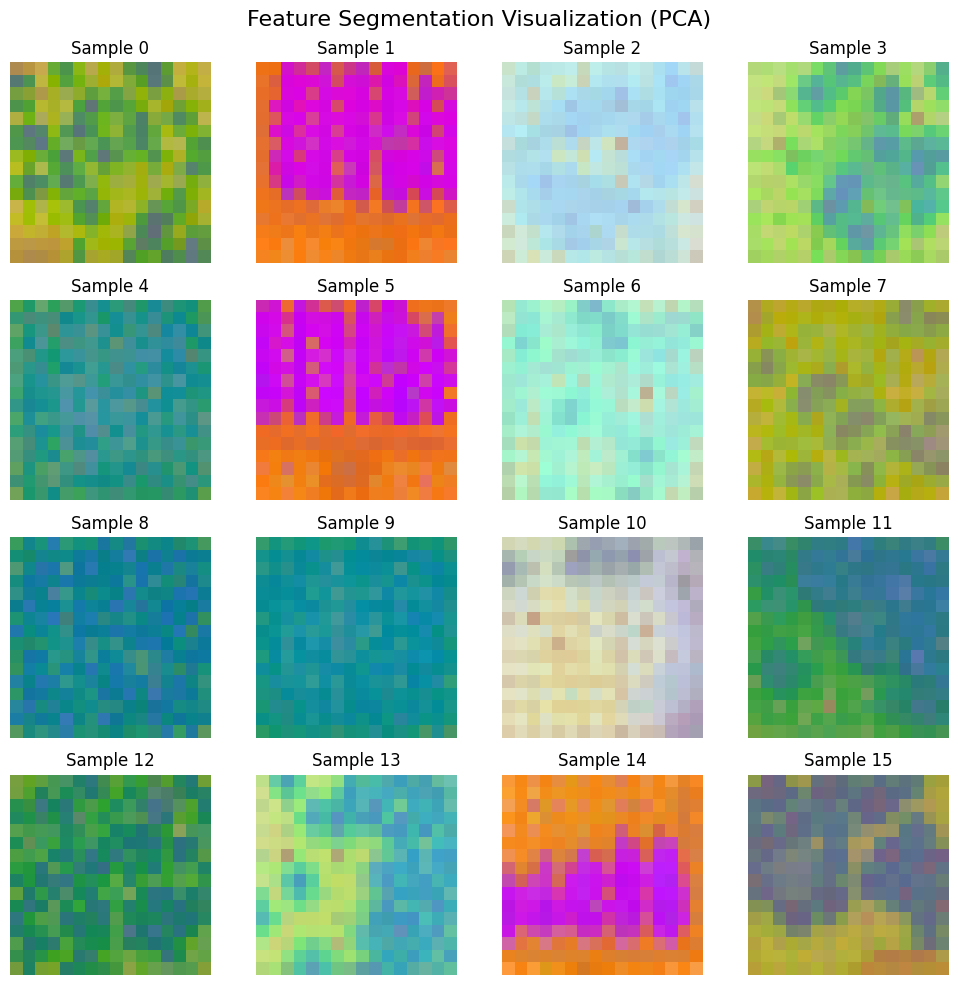

In [25]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ==========================================
# 1. 가지고 계신 피처를 여기에 연결하세요
# ==========================================
features = patch_tokens


# ==========================================
# 2. 형태 확인 및 정형화
# ==========================================
# 텐서를 Numpy로 변환
if isinstance(features, torch.Tensor):
    features_np = features.detach().cpu().numpy()
else:
    features_np = features

# 형태 확인 (Batch, Patch, Dim)이어야 함
# 만약 (Batch, Dim, H, W) 형태라면 (Batch, H*W, Dim)으로 바꿔야 함
if features_np.ndim == 4: # 예: (16, 384, 16, 16)
    B, C, H, W = features_np.shape
    features_np = features_np.transpose(0, 2, 3, 1).reshape(B, H * W, C)

B, N, C = features_np.shape
grid_size = int(np.sqrt(N)) # 256 -> 16 (16x16 그리드임을 유추)

print(f"🔹 입력 데이터 형태: {features_np.shape}")
print(f"🔹 그리드 크기 유추: {grid_size} x {grid_size}")

# ==========================================
# 3. PCA 실행 (384차원 -> 3차원 RGB)
# ==========================================
# 배치의 모든 패치를 한 줄로 펴서 PCA를 돌려야 색상이 통일됩니다.
flat_features = features_np.reshape(-1, C)

pca = PCA(n_components=3)
pca_features = pca.fit_transform(flat_features)

# 0~1로 정규화 (Min-Max Scaling)
pca_min = pca_features.min(axis=0)
pca_max = pca_features.max(axis=0)
pca_features = (pca_features - pca_min) / (pca_max - pca_min)

# 다시 이미지 격자 형태로 복구: [Batch, Height, Width, RGB]
pca_imgs = pca_features.reshape(B, grid_size, grid_size, 3)

# ==========================================
# 4. 시각화 (4x4 그리드)
# ==========================================
plt.figure(figsize=(10, 10))
plt.suptitle("Feature Segmentation Visualization (PCA)", fontsize=16)

for i in range(B):
    plt.subplot(4, 4, i + 1)
    
    # 16x16 마스크를 Nearest 방식으로 보여줌 (픽셀 느낌 살림)
    plt.imshow(pca_imgs[i], interpolation='nearest')
    plt.axis('off')
    plt.title(f"Sample {i}")

plt.tight_layout()
plt.show()

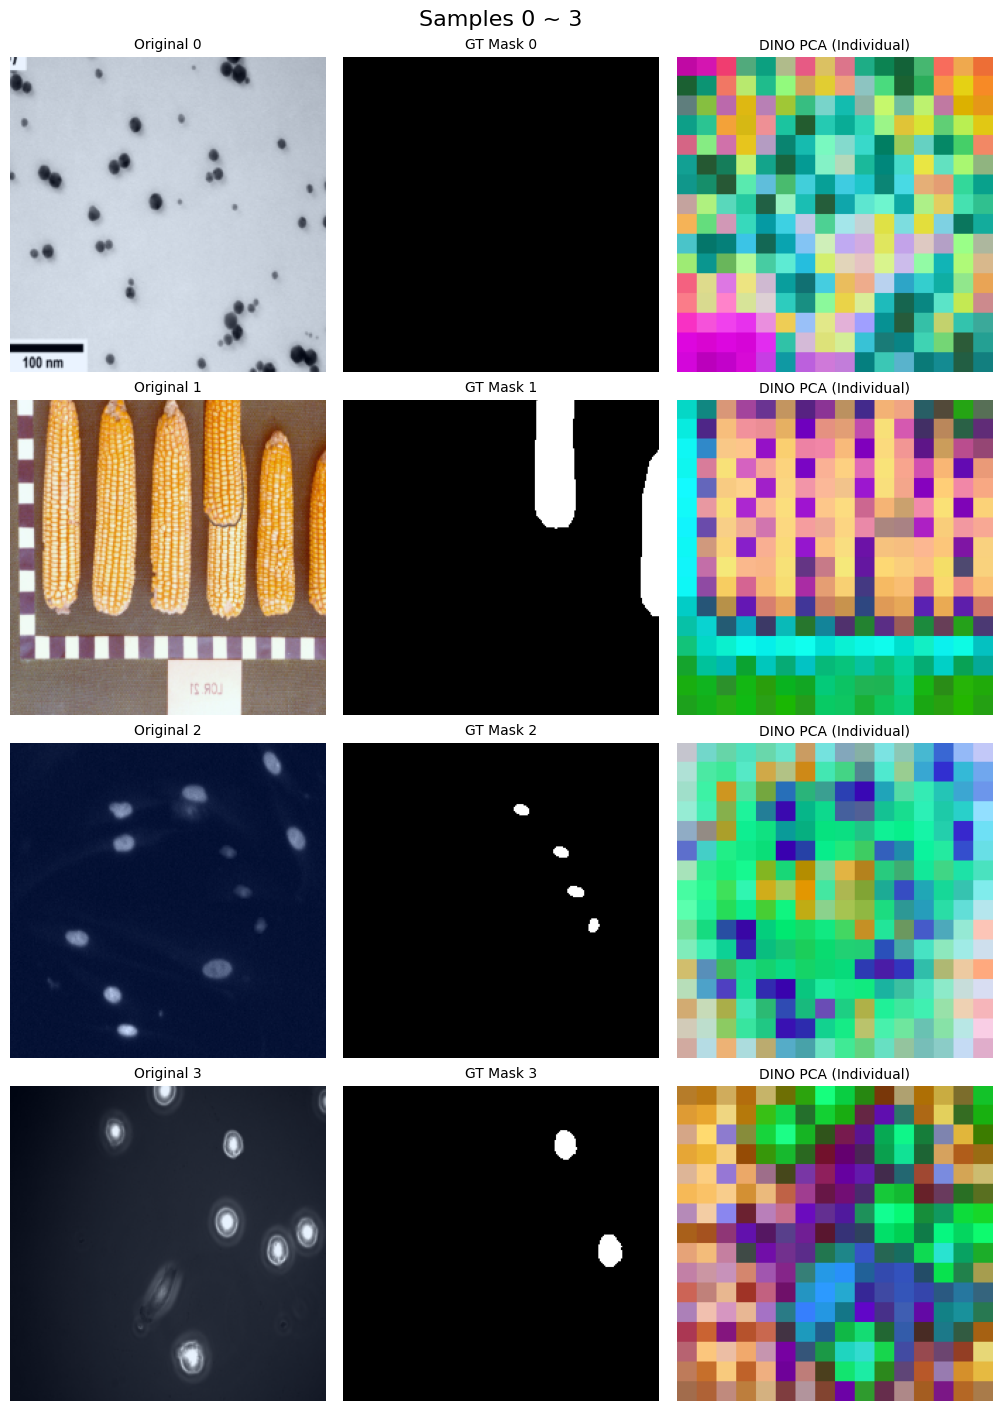

--------------------------------------------------


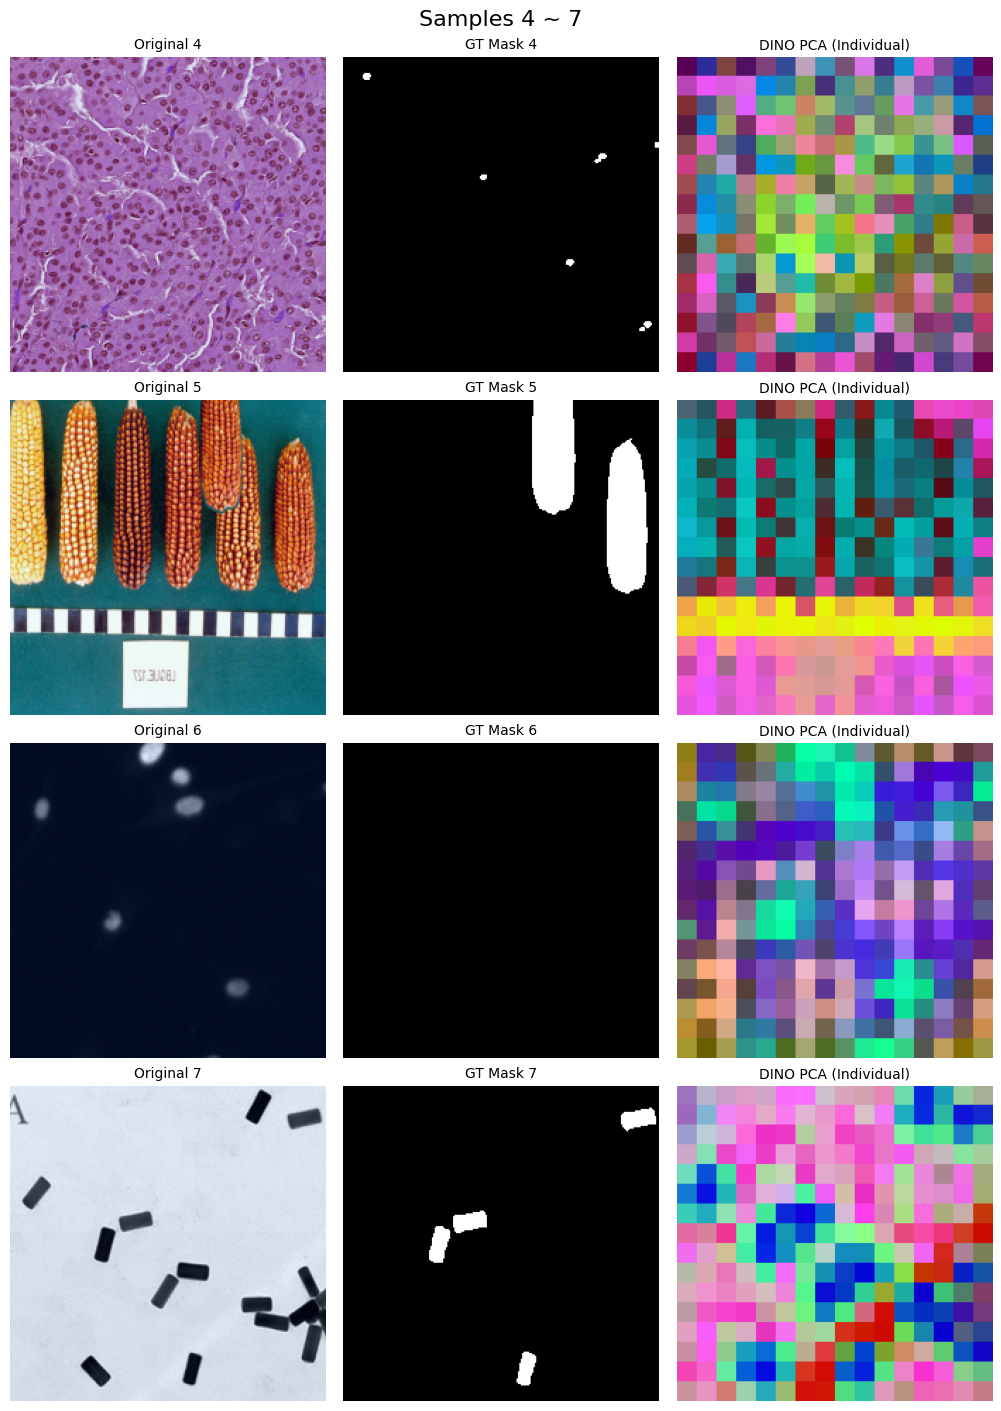

--------------------------------------------------


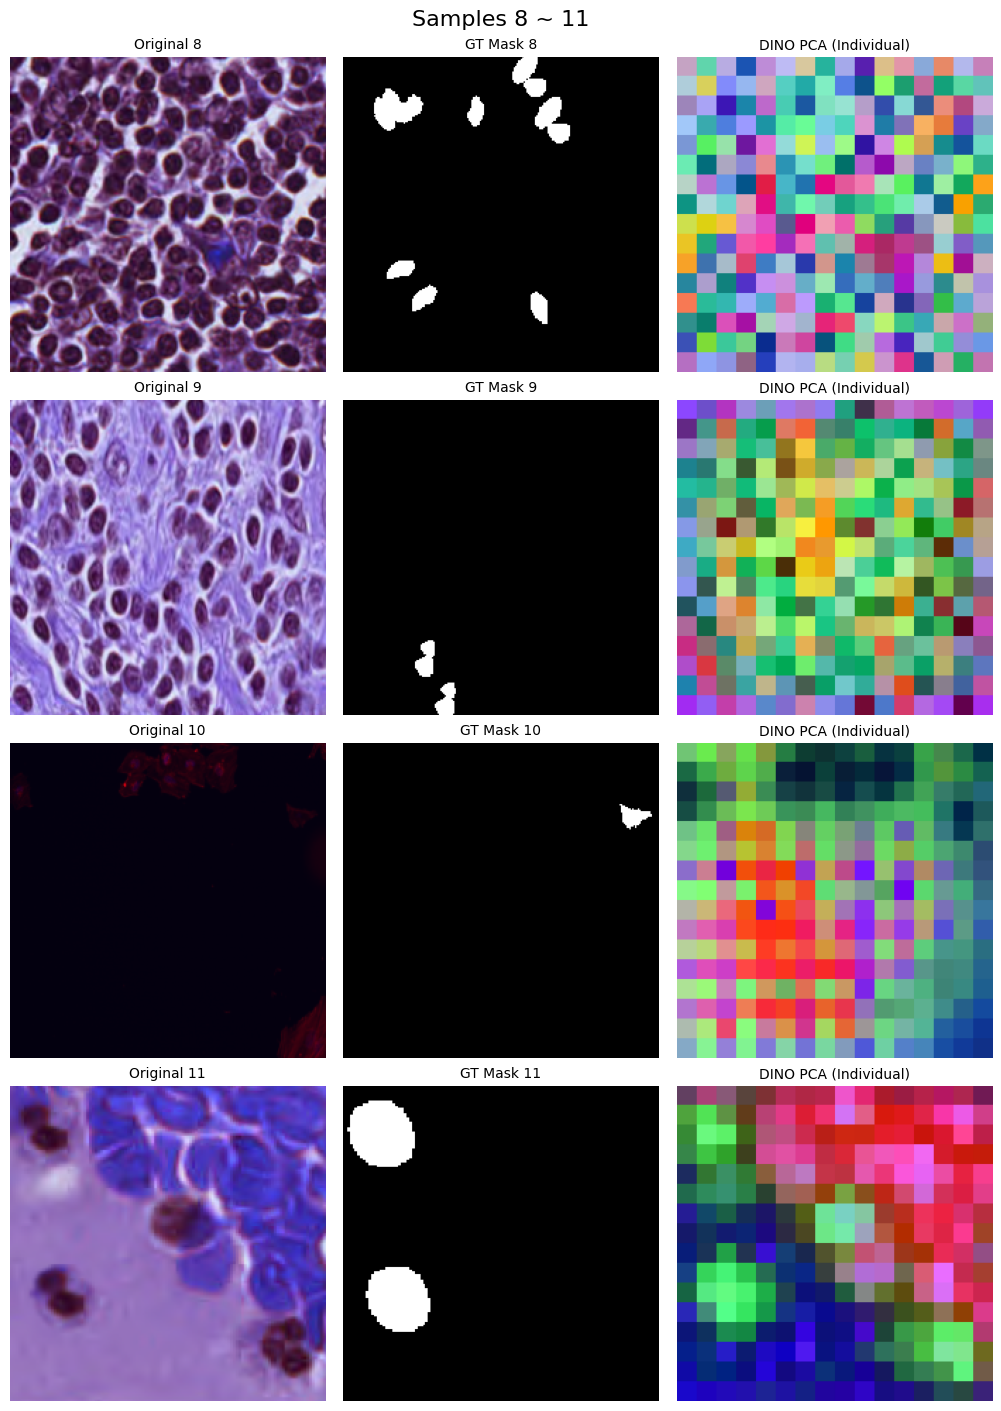

--------------------------------------------------


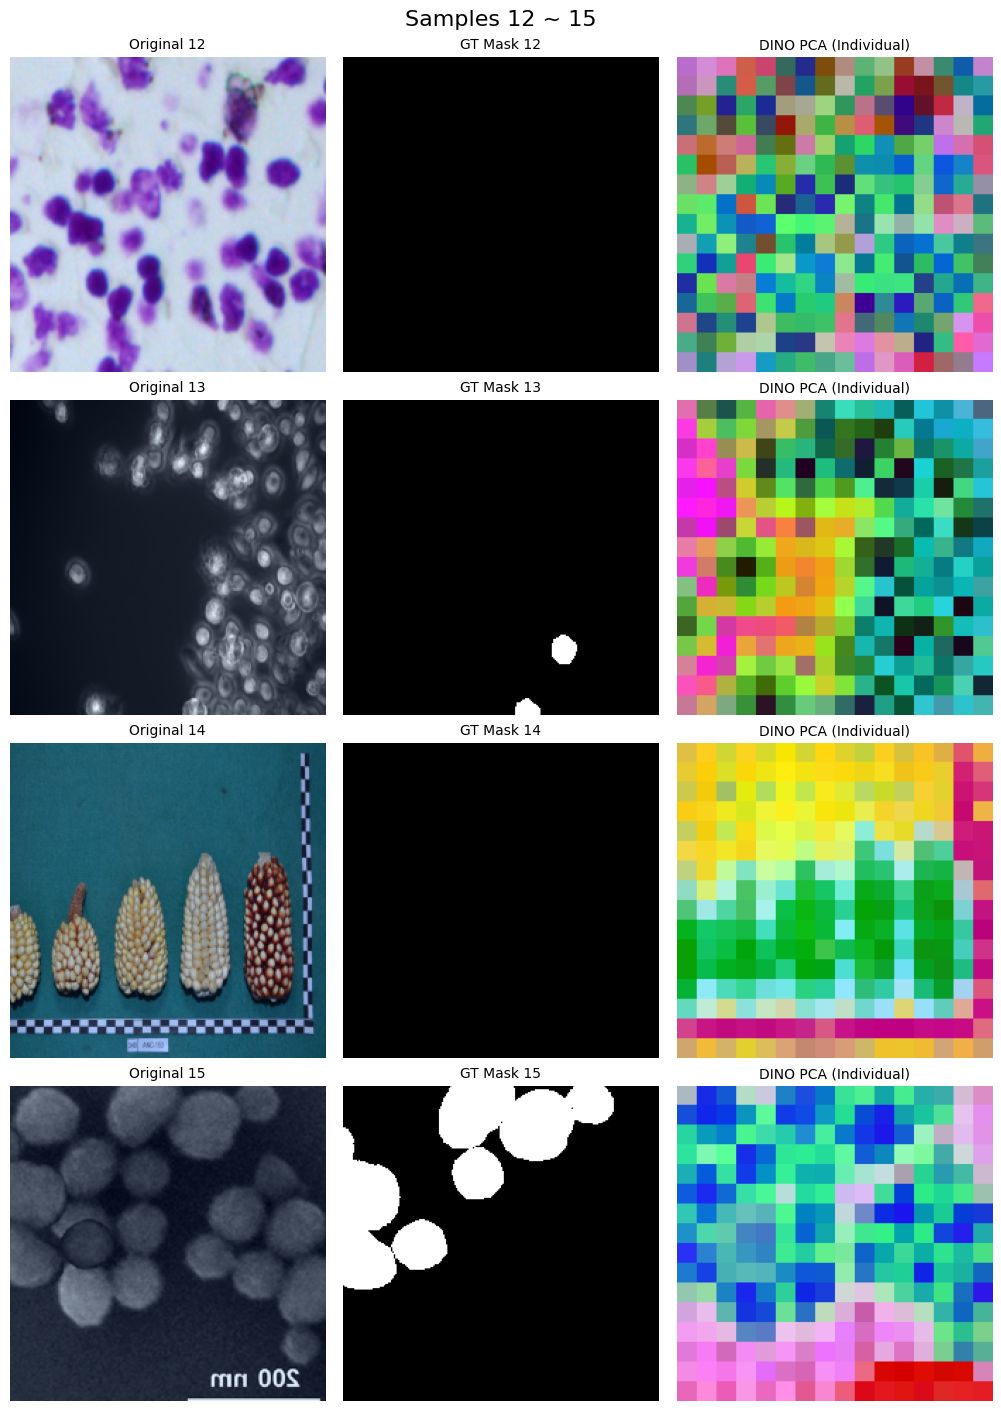

--------------------------------------------------


In [26]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from PIL import Image

# ==========================================
# 1. 데이터 준비
# ==========================================
# features = patch_tokens
# imgs = ... 
# true_masks = ...

# ==========================================
# 2. 데이터 형태 정리
# ==========================================
# (1) Features
if isinstance(features, torch.Tensor):
    features_np = features.detach().cpu().numpy()
else:
    features_np = features

if features_np.ndim == 4:
    B, C, H, W = features_np.shape
    features_np = features_np.transpose(0, 2, 3, 1).reshape(B, H * W, C)

B, N, C = features_np.shape
grid_size = int(np.sqrt(N)) # 16

# (2) Images
if isinstance(imgs, torch.Tensor):
    imgs_np = imgs.detach().cpu().numpy().transpose(0, 2, 3, 1)
else:
    imgs_np = imgs.transpose(0, 2, 3, 1)

# (3) Masks
if isinstance(true_masks, torch.Tensor):
    true_masks_np = true_masks.detach().cpu().numpy().squeeze(1)
else:
    true_masks_np = true_masks.squeeze(1)

# ==========================================
# 3. 시각화 (개별 PCA 적용)
# ==========================================
chunk_size = 4
total_samples = B

for start_idx in range(0, total_samples, chunk_size):
    end_idx = min(start_idx + chunk_size, total_samples)
    current_batch_size = end_idx - start_idx
    
    # 3개 그림 크기 강제 고정
    fig, axes = plt.subplots(nrows=current_batch_size, ncols=3, 
                             figsize=(10, 3.5 * current_batch_size),
                             constrained_layout=True)

    if current_batch_size == 1: axes = np.array([axes])

    fig.suptitle(f"Samples {start_idx} ~ {end_idx-1}", fontsize=16)

    for i in range(current_batch_size):
        idx = start_idx + i
        ax_img, ax_mask, ax_pca = axes[i]

        # --- [1] 원본 이미지 ---
        img_view = imgs_np[idx]
        img_view = (img_view - img_view.min()) / (img_view.max() - img_view.min())
        
        ax_img.imshow(img_view, aspect='equal')
        ax_img.set_title(f"Original {idx}", fontsize=10)
        ax_img.axis('off')

        # --- [2] GT 마스크 ---
        ax_mask.imshow(true_masks_np[idx], cmap='gray', aspect='equal')
        ax_mask.set_title(f"GT Mask {idx}", fontsize=10)
        ax_mask.axis('off')

        # --- [3] DINO PCA (🔥여기가 핵심: 개별 수행🔥) ---
        # 전체가 아니라 '현재 인덱스(idx)'의 특징만 가져옵니다.
        current_features = features_np[idx] # [N, C] (예: 256, 384)
        
        # PCA 모델을 매번 새로 만듭니다 (Fit을 이 이미지에만 맞춤)
        pca = PCA(n_components=3)
        pca_feat = pca.fit_transform(current_features)
        
        # 정규화도 이 이미지 기준으로 수행 (대비 극대화)
        pca_feat = (pca_feat - pca_feat.min(0)) / (pca_feat.max(0) - pca_feat.min(0))
        
        # 이미지화 및 확대
        pca_img = pca_feat.reshape(grid_size, grid_size, 3)
        
        # Nearest Neighbor로 확대해야 픽셀 경계가 선명하게 보임
        resized_pca = Image.fromarray((pca_img * 255).astype(np.uint8)).resize((224, 224), Image.NEAREST)
        
        ax_pca.imshow(resized_pca, aspect='equal')
        ax_pca.set_title(f"DINO PCA (Individual)", fontsize=10)
        ax_pca.axis('off')

    plt.show()
    print("-" * 50)

## 3-2. t-SNE 

⏳ t-SNE 계산 시작... (데이터 점 개수: 4096개)
   시간이 조금 걸릴 수 있습니다. 잠시만 기다려주세요.
✅ 계산 완료!


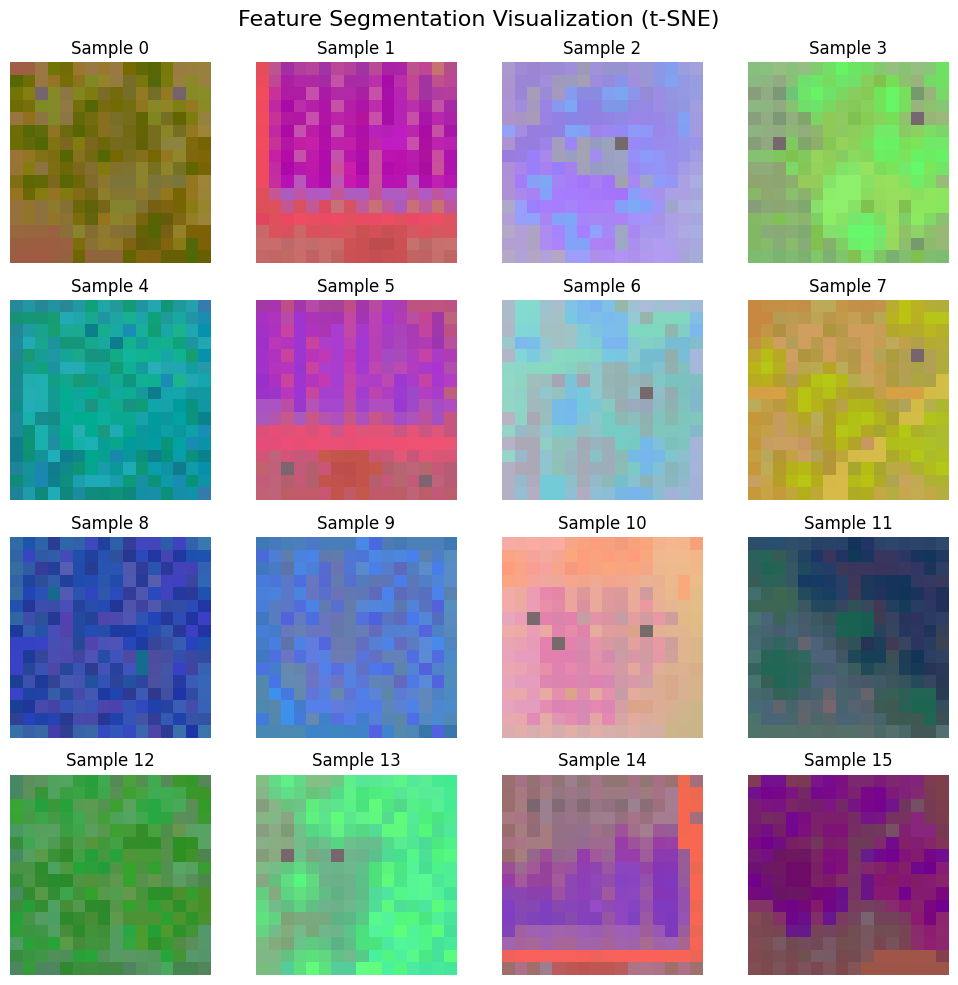

In [27]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

if isinstance(features, torch.Tensor):
    features_np = features.detach().cpu().numpy()
else:
    features_np = features

# 형태 보정: (Batch, Patch, Dim)
if features_np.ndim == 4: 
    B, C, H, W = features_np.shape
    features_np = features_np.transpose(0, 2, 3, 1).reshape(B, H * W, C)

B, N, C = features_np.shape
grid_size = int(np.sqrt(N)) # 16

# ==========================================
# 3. t-SNE 실행 (384차원 -> 3차원 RGB)
# ==========================================
print(f"⏳ t-SNE 계산 시작... (데이터 점 개수: {B * N}개)")
print("   시간이 조금 걸릴 수 있습니다. 잠시만 기다려주세요.")

flat_features = features_np.reshape(-1, C)

# t-SNE 설정
# n_components=3 (RGB 3채널로 변환)
# perplexity=30 (보통 30~50 사용, 주변 이웃을 몇 개나 볼 것인가)
tsne = TSNE(n_components=3, perplexity=30, init='pca', learning_rate='auto', random_state=42)
tsne_features = tsne.fit_transform(flat_features)

# 0~1로 정규화 (이미지 출력을 위해 Min-Max Scaling)
tsne_min = tsne_features.min(axis=0)
tsne_max = tsne_features.max(axis=0)
tsne_features = (tsne_features - tsne_min) / (tsne_max - tsne_min)

# 다시 이미지 형태(격자)로 복구
tsne_imgs = tsne_features.reshape(B, grid_size, grid_size, 3)
print("✅ 계산 완료!")

# ==========================================
# 4. 시각화
# ==========================================
plt.figure(figsize=(10, 10))
plt.suptitle("Feature Segmentation Visualization (t-SNE)", fontsize=16)

for i in range(B):
    plt.subplot(4, 4, i + 1)
    
    # Nearest 보간법으로 픽셀(패치) 느낌 살려서 출력
    plt.imshow(tsne_imgs[i], interpolation='nearest')
    plt.axis('off')
    plt.title(f"Sample {i}")

plt.tight_layout()
plt.show()

## 3-3 Cosine Similarity

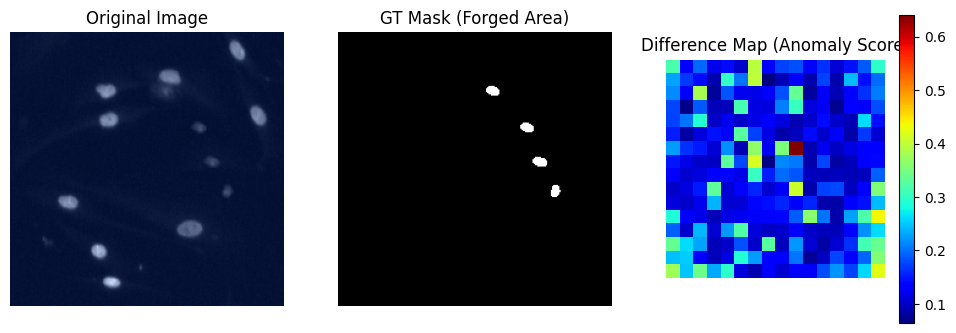

In [29]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

# ==========================================
# 1. 데이터 준비 (변수 연결)
# ==========================================
# imgs, true_masks, features 변수가 있다고 가정합니다.
# features: [16, 256, 384] (DINO 출력)
# true_masks: [16, 1, 224, 224] (GT 마스크)

idx = 2

# (1) 마스크 다운샘플링 (224x224 -> 16x16)
# 특징맵 크기에 맞춰서 GT 마스크를 줄입니다.
gt_mask = torch.tensor(true_masks_np[idx]) # [224, 224]
gt_mask_small = F.interpolate(gt_mask.unsqueeze(0).unsqueeze(0), size=(16, 16), mode='nearest').squeeze()

# (2) 특징 벡터 가져오기
feat = torch.tensor(features_np[idx]) # [256, 384]
feat = feat.view(16, 16, 384) # [H, W, Dim]

# ==========================================
# 2. "이상치 탐지" (Anomaly Score) 계산
# ==========================================
# 진짜(Authentic)라고 확신하는 부분(배경 등)의 평균 특징을 구합니다.
# 마스크가 0인 부분(정상)의 벡터들을 모음
authentic_feats = feat[gt_mask_small == 0] 

if len(authentic_feats) > 0:
    # 정상 패치들의 평균 벡터 (기준점)
    mean_authentic = authentic_feats.mean(dim=0) 
    
    # 모든 패치와 기준점 사이의 거리(Cosine Distance) 계산
    # 거리가 멀수록(1에 가까울수록) "뭔가 다르다(이상하다)"는 뜻
    
    # Cosine Similarity: 1(똑같음) ~ -1(완전반대)
    # 1 - CosSim: 0(똑같음) ~ 2(완전다름)
    
    # Flatten하여 계산
    feat_flat = feat.view(-1, 384)
    cos_sim = F.cosine_similarity(feat_flat, mean_authentic.unsqueeze(0), dim=1)
    distance_map = 1 - cos_sim
    
    # 16x16 맵으로 복원
    distance_map = distance_map.view(16, 16).numpy()

    # ==========================================
    # 3. 결과 시각화
    # ==========================================
    plt.figure(figsize=(12, 4))
    img_view = imgs_np[idx]
    img_view = (img_view - img_view.min()) / (img_view.max() - img_view.min())
    plt.subplot(1, 3, 1)
    plt.imshow(img_view)
    plt.title("Original Image")
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(true_masks_np[idx], cmap='gray')
    plt.title("GT Mask (Forged Area)")
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(distance_map, cmap='jet') # 빨갈수록 '정상'과 거리가 먼 것
    plt.colorbar()
    plt.title("Difference Map (Anomaly Score)")
    plt.axis('off')
    
    plt.show()
    
else:
    print("GT 마스크에 정상 영역(0)이 없습니다.")

# 4. Learning

In [33]:
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
from Utils.Model import SimpleDINOv2
import torch.nn as nn

# --- [IoU 계산 함수] ---
def calculate_iou(pred_logits, true_masks, threshold=0.5):
    """
    pred_logits: 모델 출력 (Sigmoid 전)
    true_masks: 정답 마스크 (0 or 1)
    """
    pred_probs = torch.sigmoid(pred_logits)
    pred_bin = (pred_probs > threshold).float()
    
    intersection = (pred_bin * true_masks).sum()
    union = pred_bin.sum() + true_masks.sum() - intersection
    
    if union == 0:
        return 1.0
    return (intersection / union).item()


# --- [설정값 Hyperparameters] ---
BATCH_SIZE = 16  # 메모리 부족하면 줄이세요 (8)
LR = 1e-3        # 학습률
NUM_EPOCHS = 20  # 에폭 수
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- [데이터 로더 준비] ---
# dataset은 아까 만든 HybridDataset 인스턴스라고 가정합니다.
# full_ds = HybridDataset(...) 

# 학습/검증 분리 (간단하게 8:2)
train_size = int(0.8 * len(full_ds))
val_size = len(full_ds) - train_size
train_ds, val_ds = torch.utils.data.random_split(full_ds, [train_size, val_size])

# ⚠️ Windows 유저 + HDF5 사용 시 num_workers=0 필수 (멀티프로세싱 에러 방지)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


# --- [모델 & 최적화 준비] ---
model = SimpleDINOv2().to(DEVICE)
params_to_train = list(model.decoder_low.parameters()) + list(model.decoder_high.parameters())
optimizer = optim.AdamW(params_to_train, lr=LR)
criterion = nn.BCEWithLogitsLoss(torch.tensor(8.3).to(DEVICE)) # 이진 분류 손실함수

# --- [🔥 학습 루프 시작] ---
print(f"\n🚀 Start Training on {DEVICE}")
best_iou = 0.0

for epoch in range(NUM_EPOCHS):
    print(f"\nExample Epoch {epoch+1}/{NUM_EPOCHS}")
    
    # 1. Train Mode
    model.decoder_low.train()
    model.decoder_high.train()
    train_loss = 0
    
    pbar = tqdm(train_loader, desc="Training")
    for imgs, masks, paths, labels in pbar: # Dataset이 4개 리턴하므로 수정
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        
        # Forward
        outputs = model(imgs) # Logits
        loss = criterion(outputs, masks)
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})
        
    avg_train_loss = train_loss / len(train_loader)
    
    # 2. Validation Mode
    model.decoder_low.eval()
    model.decoder_high.eval()
    val_loss = 0
    val_iou = 0
    
    with torch.no_grad():
        for imgs, masks, paths, labels in tqdm(val_loader, desc="Validating"):
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            
            outputs = model(imgs)
            loss = criterion(outputs, masks)
            
            val_loss += loss.item()
            val_iou += calculate_iou(outputs, masks)
            
    avg_val_loss = val_loss / len(val_loader)
    avg_val_iou = val_iou / len(val_loader)
    
    print(f"📉 Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    print(f"🏆 Val IoU: {avg_val_iou:.4f}")
    
    # 3. 모델 저장 (IoU 갱신 시)
    if avg_val_iou > best_iou:
        print(f"💾 Best Model Updated! ({best_iou:.4f} -> {avg_val_iou:.4f})")
        best_iou = avg_val_iou
        torch.save(model.state_dict(), "best_dino_segmentation.pth")

🚀 Loading Backbone: dinov2_vits14 ...


Using cache found in C:\Users\user/.cache\torch\hub\facebookresearch_dinov2_main



🚀 Start Training on cuda

Example Epoch 1/20


Validating: 100%|██████████| 65/65 [00:02<00:00, 23.82it/s]


📉 Train Loss: 1.7066 | Val Loss: 0.9483
🏆 Val IoU: 0.0154
💾 Best Model Updated! (0.0000 -> 0.0154)

Example Epoch 2/20


...

📉 Train Loss: 0.6597 | Val Loss: 0.7612
🏆 Val IoU: 0.2056

Example Epoch 19/20


Validating: 100%|██████████| 65/65 [00:02<00:00, 24.68it/s]


📉 Train Loss: 0.6453 | Val Loss: 0.7411
🏆 Val IoU: 0.2250

Example Epoch 20/20


Validating: 100%|██████████| 65/65 [00:02<00:00, 24.53it/s]

📉 Train Loss: 0.6348 | Val Loss: 0.7536
🏆 Val IoU: 0.2219


In [34]:
for i, (img, mask, path, is_forged) in enumerate(val_loader):
    if is_forged.sum() > 8:
        first_batch = (img.to(device), mask.to(device), is_forged)
        break


# forward_features 메서드 사용

with torch.no_grad():
    dict_features = dino_model.forward_features(first_batch[0])
    
    # 1. CLS Token (전체 요약)
    cls_token = dict_features["x_norm_clstoken"]
    
    # 2. Patch Tokens (각 위치별 특징)
    patch_tokens = dict_features["x_norm_patchtokens"]

print(f"Patch Tokens 크기: {patch_tokens.shape}") 
# 결과: [1, 256, 384] -> 224x224 이미지를 14x14(=196)개가 아니라
# 레지스터 토큰 등을 포함하거나 16x16 패치 개수(256)만큼 나옵니다.
imgs = first_batch[0]
true_masks = first_batch[1]
print(imgs.shape)
print(true_masks.shape)

Patch Tokens 크기: torch.Size([16, 256, 384])
torch.Size([16, 3, 224, 224])
torch.Size([16, 1, 224, 224])


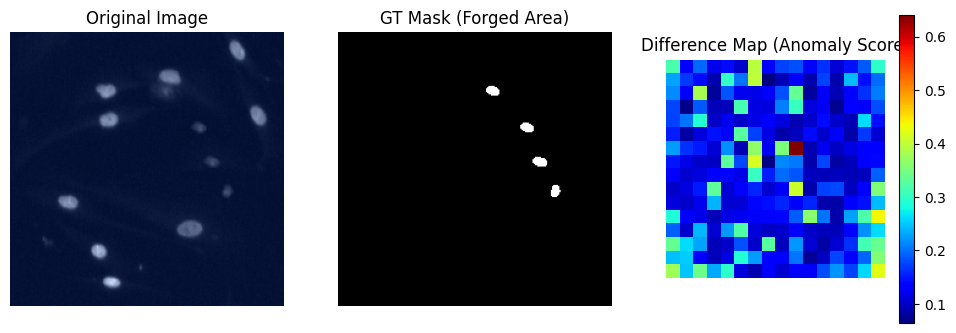

In [35]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

# ==========================================
# 1. 데이터 준비 (변수 연결)
# ==========================================
# imgs, true_masks, features 변수가 있다고 가정합니다.
# features: [16, 256, 384] (DINO 출력)
# true_masks: [16, 1, 224, 224] (GT 마스크)

idx = 2

# (1) 마스크 다운샘플링 (224x224 -> 16x16)
# 특징맵 크기에 맞춰서 GT 마스크를 줄입니다.
gt_mask = torch.tensor(true_masks_np[idx]) # [224, 224]
gt_mask_small = F.interpolate(gt_mask.unsqueeze(0).unsqueeze(0), size=(16, 16), mode='nearest').squeeze()

# (2) 특징 벡터 가져오기
feat = torch.tensor(features_np[idx]) # [256, 384]
feat = feat.view(16, 16, 384) # [H, W, Dim]

# ==========================================
# 2. "이상치 탐지" (Anomaly Score) 계산
# ==========================================
# 진짜(Authentic)라고 확신하는 부분(배경 등)의 평균 특징을 구합니다.
# 마스크가 0인 부분(정상)의 벡터들을 모음
authentic_feats = feat[gt_mask_small == 0] 

if len(authentic_feats) > 0:
    # 정상 패치들의 평균 벡터 (기준점)
    mean_authentic = authentic_feats.mean(dim=0) 
    
    # 모든 패치와 기준점 사이의 거리(Cosine Distance) 계산
    # 거리가 멀수록(1에 가까울수록) "뭔가 다르다(이상하다)"는 뜻
    
    # Cosine Similarity: 1(똑같음) ~ -1(완전반대)
    # 1 - CosSim: 0(똑같음) ~ 2(완전다름)
    
    # Flatten하여 계산
    feat_flat = feat.view(-1, 384)
    cos_sim = F.cosine_similarity(feat_flat, mean_authentic.unsqueeze(0), dim=1)
    distance_map = 1 - cos_sim
    
    # 16x16 맵으로 복원
    distance_map = distance_map.view(16, 16).numpy()

    # ==========================================
    # 3. 결과 시각화
    # ==========================================
    plt.figure(figsize=(12, 4))
    img_view = imgs_np[idx]
    img_view = (img_view - img_view.min()) / (img_view.max() - img_view.min())
    plt.subplot(1, 3, 1)
    plt.imshow(img_view)
    plt.title("Original Image")
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(true_masks_np[idx], cmap='gray')
    plt.title("GT Mask (Forged Area)")
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(distance_map, cmap='jet') # 빨갈수록 '정상'과 거리가 먼 것
    plt.colorbar()
    plt.title("Difference Map (Anomaly Score)")
    plt.axis('off')
    
    plt.show()
    
else:
    print("GT 마스크에 정상 영역(0)이 없습니다.")

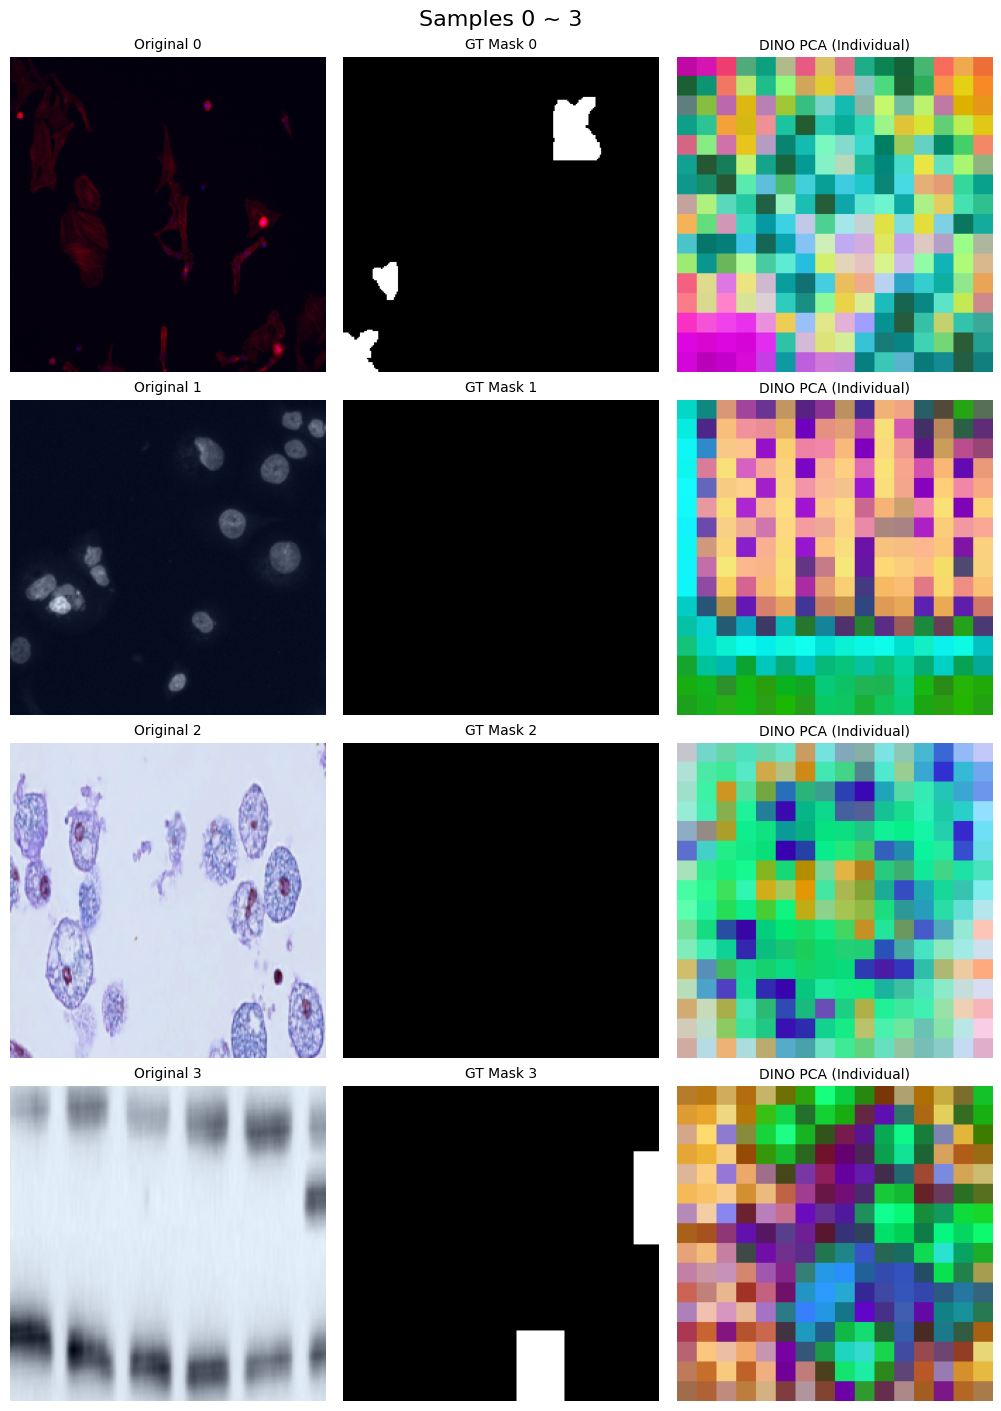

--------------------------------------------------


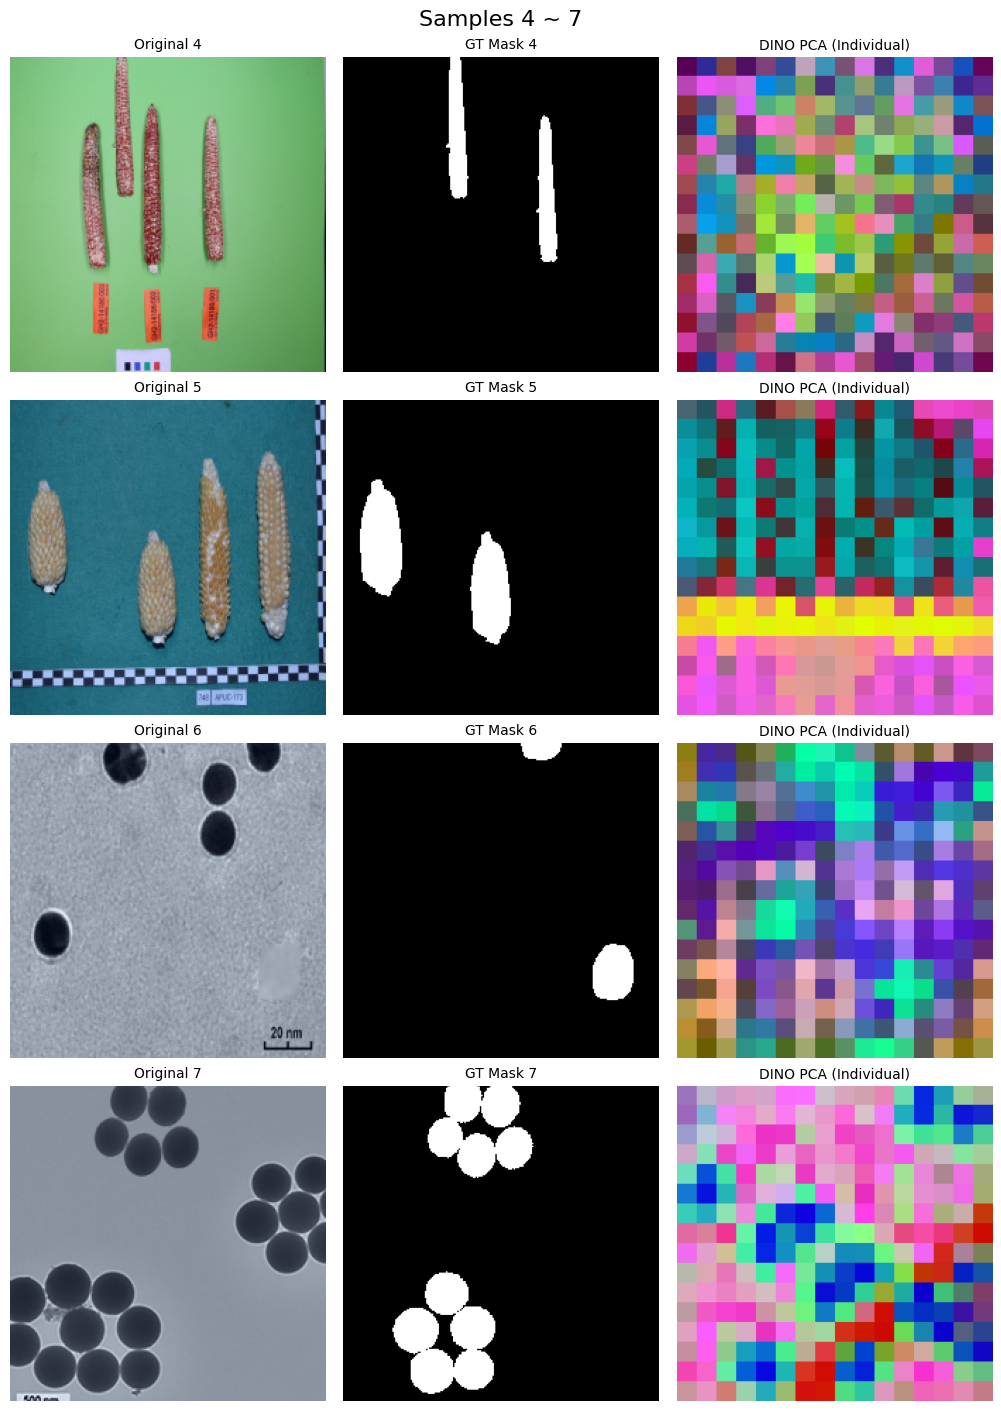

--------------------------------------------------


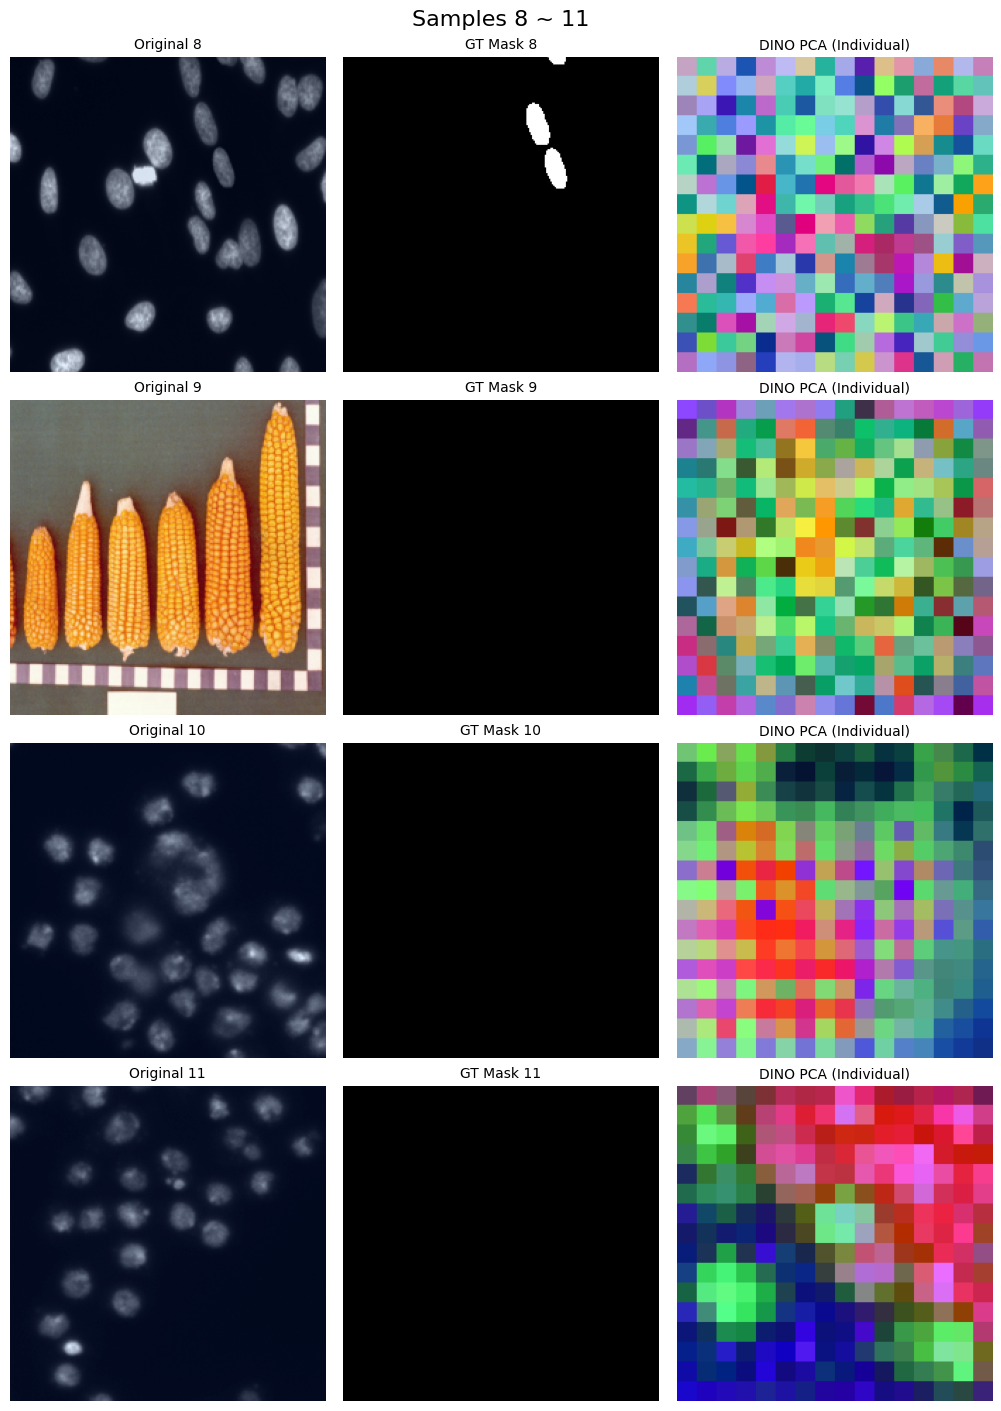

--------------------------------------------------


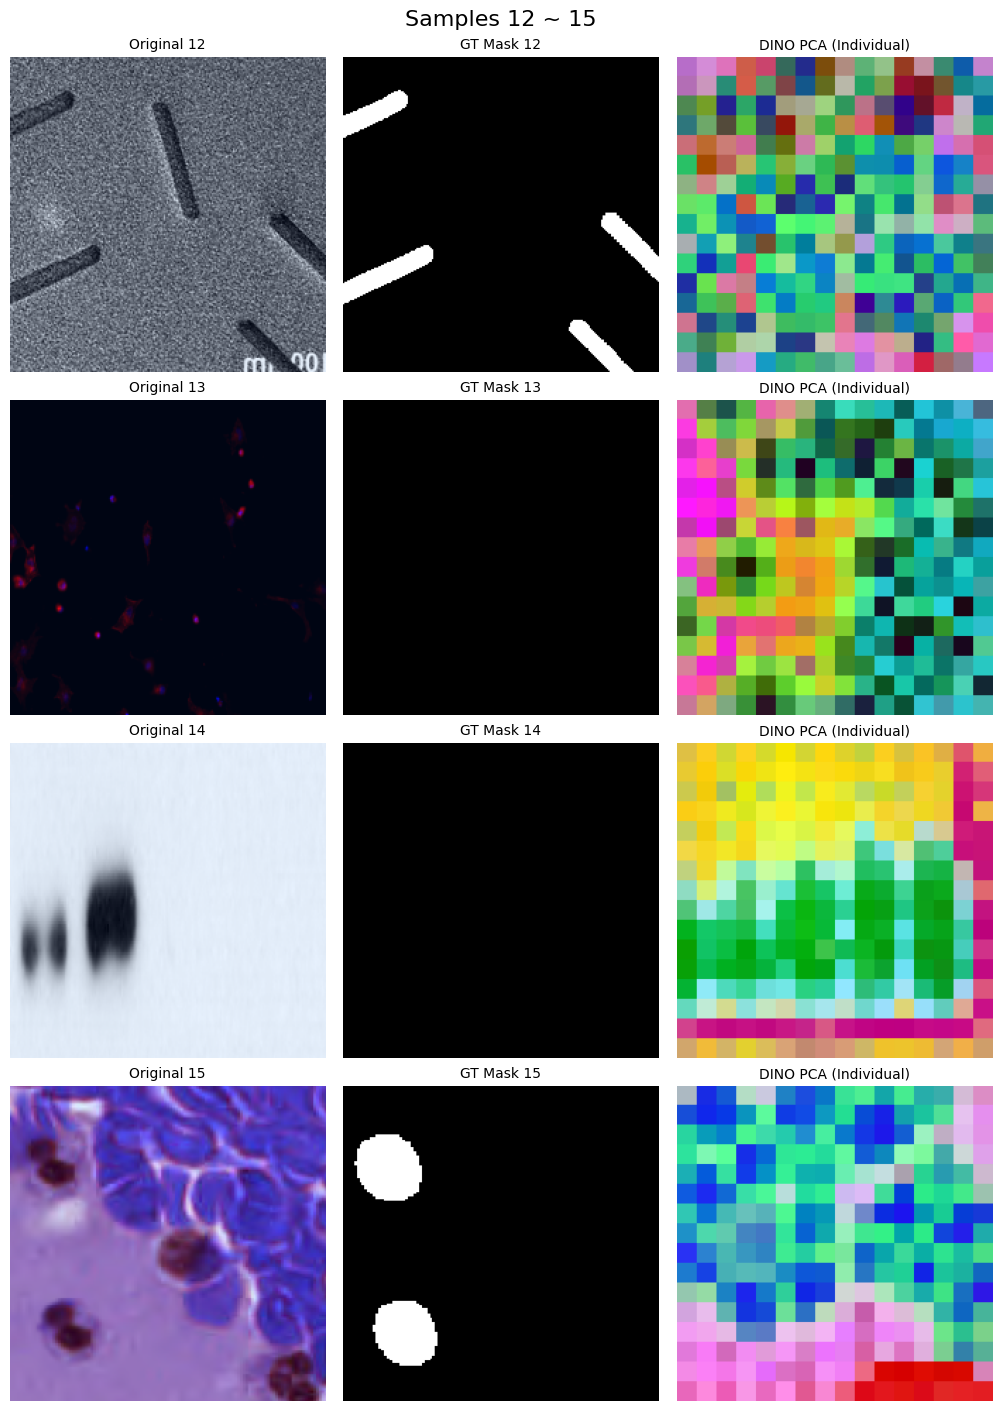

--------------------------------------------------


In [36]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from PIL import Image

# ==========================================
# 1. 데이터 준비
# ==========================================
# features = patch_tokens
# imgs = ... 
# true_masks = ...

# ==========================================
# 2. 데이터 형태 정리
# ==========================================
# (1) Features
if isinstance(features, torch.Tensor):
    features_np = features.detach().cpu().numpy()
else:
    features_np = features

if features_np.ndim == 4:
    B, C, H, W = features_np.shape
    features_np = features_np.transpose(0, 2, 3, 1).reshape(B, H * W, C)

B, N, C = features_np.shape
grid_size = int(np.sqrt(N)) # 16

# (2) Images
if isinstance(imgs, torch.Tensor):
    imgs_np = imgs.detach().cpu().numpy().transpose(0, 2, 3, 1)
else:
    imgs_np = imgs.transpose(0, 2, 3, 1)

# (3) Masks
if isinstance(true_masks, torch.Tensor):
    true_masks_np = true_masks.detach().cpu().numpy().squeeze(1)
else:
    true_masks_np = true_masks.squeeze(1)

# ==========================================
# 3. 시각화 (개별 PCA 적용)
# ==========================================
chunk_size = 4
total_samples = B

for start_idx in range(0, total_samples, chunk_size):
    end_idx = min(start_idx + chunk_size, total_samples)
    current_batch_size = end_idx - start_idx
    
    # 3개 그림 크기 강제 고정
    fig, axes = plt.subplots(nrows=current_batch_size, ncols=3, 
                             figsize=(10, 3.5 * current_batch_size),
                             constrained_layout=True)

    if current_batch_size == 1: axes = np.array([axes])

    fig.suptitle(f"Samples {start_idx} ~ {end_idx-1}", fontsize=16)

    for i in range(current_batch_size):
        idx = start_idx + i
        ax_img, ax_mask, ax_pca = axes[i]

        # --- [1] 원본 이미지 ---
        img_view = imgs_np[idx]
        img_view = (img_view - img_view.min()) / (img_view.max() - img_view.min())
        
        ax_img.imshow(img_view, aspect='equal')
        ax_img.set_title(f"Original {idx}", fontsize=10)
        ax_img.axis('off')

        # --- [2] GT 마스크 ---
        ax_mask.imshow(true_masks_np[idx], cmap='gray', aspect='equal')
        ax_mask.set_title(f"GT Mask {idx}", fontsize=10)
        ax_mask.axis('off')

        # --- [3] DINO PCA (🔥여기가 핵심: 개별 수행🔥) ---
        # 전체가 아니라 '현재 인덱스(idx)'의 특징만 가져옵니다.
        current_features = features_np[idx] # [N, C] (예: 256, 384)
        
        # PCA 모델을 매번 새로 만듭니다 (Fit을 이 이미지에만 맞춤)
        pca = PCA(n_components=3)
        pca_feat = pca.fit_transform(current_features)
        
        # 정규화도 이 이미지 기준으로 수행 (대비 극대화)
        pca_feat = (pca_feat - pca_feat.min(0)) / (pca_feat.max(0) - pca_feat.min(0))
        
        # 이미지화 및 확대
        pca_img = pca_feat.reshape(grid_size, grid_size, 3)
        
        # Nearest Neighbor로 확대해야 픽셀 경계가 선명하게 보임
        resized_pca = Image.fromarray((pca_img * 255).astype(np.uint8)).resize((224, 224), Image.NEAREST)
        
        ax_pca.imshow(resized_pca, aspect='equal')
        ax_pca.set_title(f"DINO PCA (Individual)", fontsize=10)
        ax_pca.axis('off')

    plt.show()
    print("-" * 50)